# F6 — Week 11 Performance Review

**Objective**: Review the optimisation performance of F6 across all 11 submission rounds and propose strategy for next submission.

**Function**: F6 (5D input, 1D output, maximisation)

**Week 10 Strategy**: SFGP Matérn-1.5 ARD + rank-based interior penalty + qLogNEI q=4 + noise_lb=1e-3 + 5000 raw samples + milk≥0.12 constraint.

**F6 is the best-performing function** with 4/10 improvements and NOT stalling. This notebook loads the Week 11 data, visualises convergence and input-space coverage, evaluates performance, and proposes strategy improvements.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

# ── Function Configuration ──
FUNC_NUM = 6
N_DIMS = 5
N_INITIAL = 20
WEEK = 11
USE_LOG_SCALE = False
DATA_DIR = '../../data/f6/'

## Step 1 — Load Data

In [22]:
inputs = np.load(f'{DATA_DIR}updated_inputs - Week {WEEK}.npy')
outputs = np.load(f'{DATA_DIR}updated_outputs - Week {WEEK}.npy')

n_total = len(outputs)
n_submissions = n_total - N_INITIAL

print(f'F{FUNC_NUM} — Week {WEEK} Data Summary')
print(f'  Input dimensions:  {N_DIMS}')
print(f'  Total samples:     {n_total}')
print(f'  Initial samples:   {N_INITIAL}')
print(f'  Submissions:       {n_submissions}')
print(f'  Input shape:       {inputs.shape}')
print(f'  Output shape:      {outputs.shape}')
print(f'  Best output:       {outputs.max():.6g}')
print(f'  Worst output:      {outputs.min():.6g}')
print()

print('Sample | ' + ' | '.join([f'x{j+1:d}' for j in range(N_DIMS)]) + ' | y')
print('-' * (10 + N_DIMS * 12 + 15))
for i in range(n_total):
    label = 'init' if i < N_INITIAL else f'wk{i - N_INITIAL + 3}'
    row = f'{i+1:>4d}({label:>4s}) | '
    row += ' | '.join([f'{inputs[i, j]:.6f}' for j in range(N_DIMS)])
    row += f' | {outputs[i]:.6g}'
    print(row)

F6 — Week 11 Data Summary
  Input dimensions:  5
  Total samples:     31
  Initial samples:   20
  Submissions:       11
  Input shape:       (31, 5)
  Output shape:      (31,)
  Best output:       -0.11149
  Worst output:      -2.57117

Sample | x1 | x2 | x3 | x4 | x5 | y
-------------------------------------------------------------------------------------
   1(init) | 0.728186 | 0.154693 | 0.732552 | 0.693997 | 0.056401 | -0.714265
   2(init) | 0.242384 | 0.844100 | 0.577809 | 0.679021 | 0.501953 | -1.20996
   3(init) | 0.729523 | 0.748106 | 0.679775 | 0.356552 | 0.671054 | -1.6722
   4(init) | 0.770620 | 0.114404 | 0.046780 | 0.648324 | 0.273549 | -1.53606
   5(init) | 0.618812 | 0.331802 | 0.187288 | 0.756238 | 0.328835 | -0.829237
   6(init) | 0.784958 | 0.910682 | 0.708120 | 0.959225 | 0.004911 | -1.24705
   7(init) | 0.145111 | 0.896685 | 0.896322 | 0.726272 | 0.236272 | -1.23379
   8(init) | 0.945069 | 0.288459 | 0.978806 | 0.961656 | 0.598016 | -1.69434
   9(init) | 0.125720 |

## Step 2 — Convergence Plot

Running best (maximum) objective value over all samples.

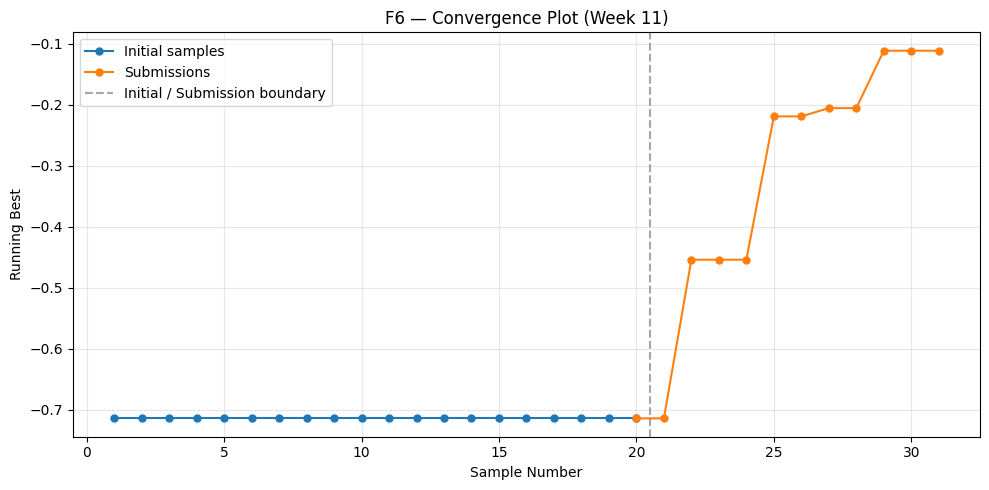

In [23]:
running_best = np.maximum.accumulate(outputs)

fig, ax = plt.subplots(figsize=(10, 5))
x_all = np.arange(1, n_total + 1)

ax.plot(x_all[:N_INITIAL], running_best[:N_INITIAL], 'o-', color='tab:blue',
        label='Initial samples', markersize=5)
ax.plot(x_all[N_INITIAL-1:], running_best[N_INITIAL-1:], 'o-', color='tab:orange',
        label='Submissions', markersize=5)
ax.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
           label='Initial / Submission boundary')

ax.set_xlabel('Sample Number')
ax.set_ylabel('Running Best')
ax.set_title(f'F{FUNC_NUM} — Convergence Plot (Week {WEEK})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Step 3 — 2D Pair Plots

Scatter plots of each unique pair of input dimensions showing spatial coverage. Initial samples in **blue**, submission samples in **orange** (numbered by week).

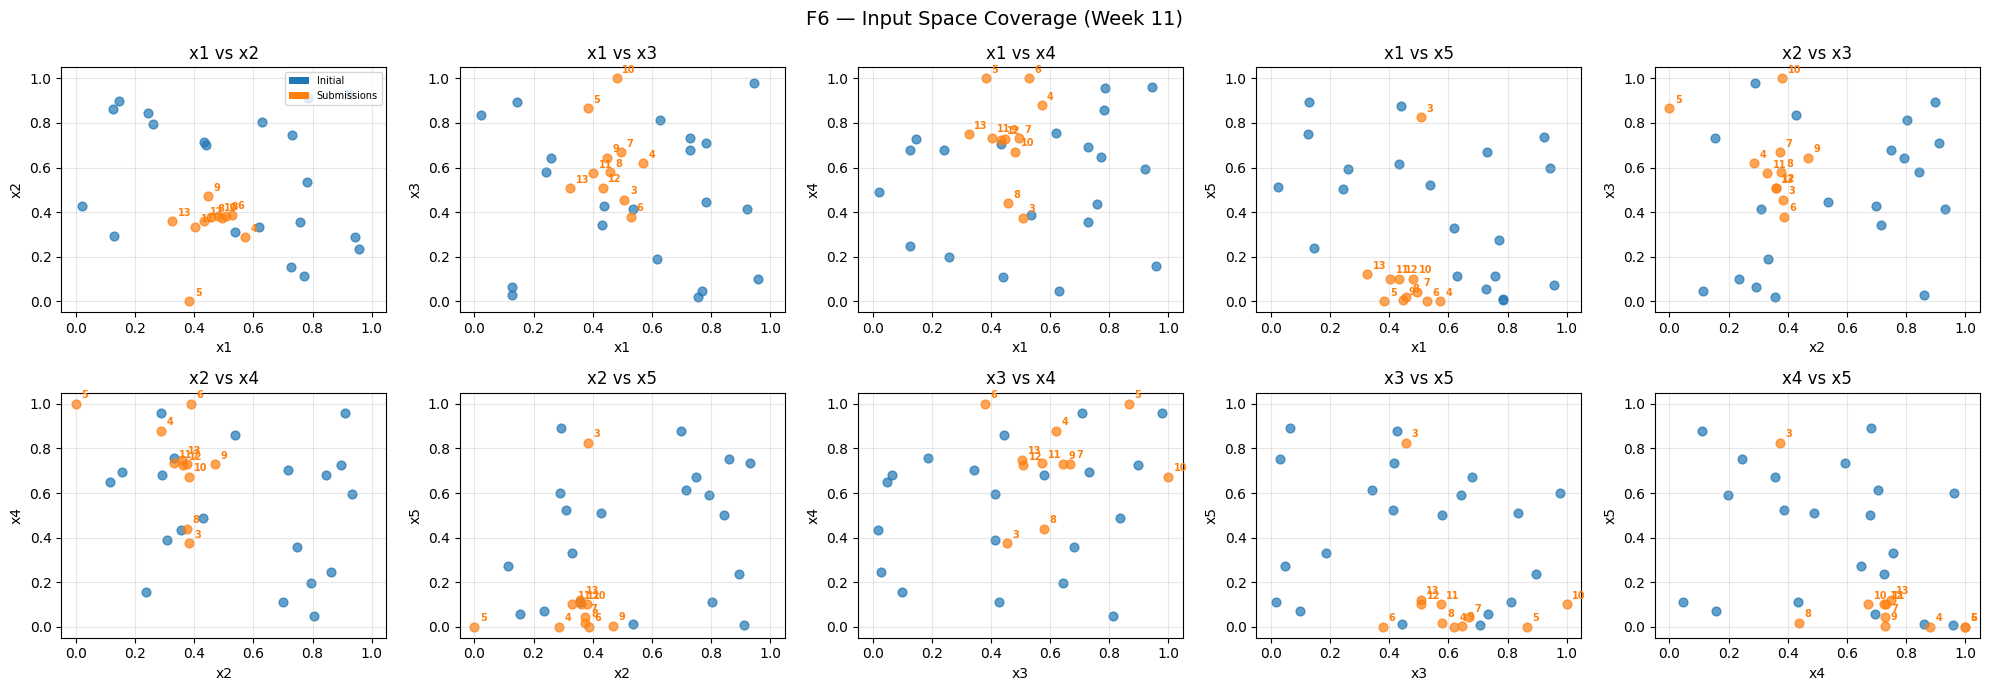

In [24]:
pairs = list(combinations(range(N_DIMS), 2))
n_pairs = len(pairs)

n_cols = min(n_pairs, 5)
n_rows = math.ceil(n_pairs / n_cols)
fig_width = n_cols * 4
fig_height = n_rows * 3.5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                         squeeze=False)

for idx, (di, dj) in enumerate(pairs):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]

    ax.scatter(inputs[:N_INITIAL, di], inputs[:N_INITIAL, dj],
               c='tab:blue', marker='o', s=40, alpha=0.7, label='Initial')

    for k in range(N_INITIAL, n_total):
        week_num = k - N_INITIAL + 3
        ax.scatter(inputs[k, di], inputs[k, dj],
                   c='tab:orange', marker='o', s=40, alpha=0.7)
        ax.annotate(str(week_num), (inputs[k, di], inputs[k, dj]),
                    textcoords='offset points', xytext=(4, 4),
                    fontsize=7, color='tab:orange', fontweight='bold')

    ax.set_xlabel(f'x{di+1}')
    ax.set_ylabel(f'x{dj+1}')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'x{di+1} vs x{dj+1}')
    ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='tab:blue', label='Initial'),
                   Patch(facecolor='tab:orange', label='Submissions')]
axes[0][0].legend(handles=legend_elements, loc='upper right', fontsize=7)

for idx in range(n_pairs, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row][col].set_visible(False)

fig.suptitle(f'F{FUNC_NUM} — Input Space Coverage (Week {WEEK})', fontsize=14)
fig.tight_layout()
plt.show()

## Step 4 — Performance Evaluation

### Week 10 Strategy

- **Surrogate**: SFGP Matérn-1.5 ARD + rank-based interior penalty
- **Acquisition**: qLogNEI q=4 + 5000 raw samples + noise_lb=1e-3
- **Constraint**: milk ≥ 0.12 (domain constraint for F6)
- **Status**: Best-performing function — 4/10 improvements, NOT stalling

### Performance Summary

In [25]:
running_best = np.maximum.accumulate(outputs)
init_best = running_best[N_INITIAL - 1]

improvements = 0
consec_no_improve = 0
max_consec_no_improve = 0
prev_best = init_best

for j in range(N_INITIAL, n_total):
    if running_best[j] > prev_best:
        improvements += 1
        consec_no_improve = 0
    else:
        consec_no_improve += 1
        max_consec_no_improve = max(max_consec_no_improve, consec_no_improve)
    prev_best = running_best[j]

stalling = max_consec_no_improve >= 3

print(f'Best value (initial):     {init_best:.6g}')
print(f'Best value (final):       {running_best[-1]:.6g}')
print(f'Improvements:             {improvements}/{n_submissions}')
print(f'Max consecutive no-improve: {max_consec_no_improve}')
print(f'Stalling (≥3 consec):     {stalling}')
print()

print('Week | Output         | Best-so-far    | Improved?')
print('-' * 55)
for j in range(N_INITIAL, n_total):
    week_num = j - N_INITIAL + 3
    improved = '✓' if (j == N_INITIAL and outputs[j] > init_best) or \
               (j > N_INITIAL and running_best[j] > running_best[j-1]) else '✗'
    print(f'  {week_num:>2d} | {outputs[j]:>14.6g} | {running_best[j]:>14.6g} | {improved}')

Best value (initial):     -0.714265
Best value (final):       -0.11149
Improvements:             4/11
Max consecutive no-improve: 2
Stalling (≥3 consec):     False

Week | Output         | Best-so-far    | Improved?
-------------------------------------------------------
   3 |       -1.44505 |      -0.714265 | ✗
   4 |       -0.45413 |       -0.45413 | ✓
   5 |       -0.94577 |       -0.45413 | ✗
   6 |      -0.636347 |       -0.45413 | ✗
   7 |      -0.219187 |      -0.219187 | ✓
   8 |      -0.606701 |      -0.219187 | ✗
   9 |        -0.2056 |        -0.2056 | ✓
  10 |      -0.593202 |        -0.2056 | ✗
  11 |       -0.11149 |       -0.11149 | ✓
  12 |      -0.137238 |       -0.11149 | ✗
  13 |      -0.298257 |       -0.11149 | ✗


## Step 5 — Strategy Proposals for Next Submission

Review the performance metrics and convergence plot above. Key considerations for F6:

1. **F6 is the best-performing function** — 4/10 improvements, no stalling. The current strategy is working.

2. **If week 11 improved**: Keep the winning configuration:
   - Same surrogate (SFGP Matérn-1.5 ARD + rank-based interior penalty)
   - Same acquisition (qLogNEI q=4 + noise_lb=1e-3)
   - Retain milk ≥ 0.12 constraint
   - Consider mild exploitation shift: reduce q to 3 to focus more tightly

3. **If week 11 did NOT improve**: First non-stalling miss — be cautious about over-reacting:
   - **Keep the same strategy for one more round** — a single miss doesn't warrant major changes
   - **Increase raw_samples from 5000 to 8000** for better 5D coverage
   - **Increase MLL restarts to 50** (from current) for more robust hyperparameters
   - **Check ARD lengthscales** — identify if any of the 5 dimensions are becoming less important

4. **General**: F6 has domain constraints (milk ≥ 0.12) which shape the feasible region. The rank-based interior penalty + domain constraint combination has been effective. The 5D search space is large but the penalty mechanism is guiding exploration well.

## ARD Feature Relevance Analysis

Automatic Relevance Determination (ARD) assigns a separate lengthscale parameter to each input dimension in the GP kernel. **Smaller lengthscale → the model is more sensitive to that dimension → higher relevance.**

Below we fit a SingleTaskGP with a Matérn-1.5 ARD kernel on the current data, extract the per-dimension lengthscales, and visualise the normalised relevance scores. The output transform matches the optimisation notebook: Standardize(m=1).

In [ ]:
import torch
import gpytorch
from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.priors import GammaPrior
from gpytorch.constraints import GreaterThan

# Prepare training data
X_train = torch.tensor(inputs, dtype=torch.float64)
Y_train = torch.tensor(outputs, dtype=torch.float64).unsqueeze(-1)

# Fit SingleTaskGP with Matérn-1.5 ARD kernel
covar_module = ScaleKernel(
    MaternKernel(nu=1.5, ard_num_dims=N_DIMS, lengthscale_prior=GammaPrior(3.0, 6.0)),
    outputscale_prior=GammaPrior(2.0, 0.15),
)
model = SingleTaskGP(X_train, Y_train, covar_module=covar_module, outcome_transform=Standardize(m=1))
model.likelihood.noise_covar.register_constraint("raw_noise", GreaterThan(1e-3))
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)

# Extract ARD lengthscales
lengthscales = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
dim_names = ["flour", "sugar", "eggs", "butter", "milk"]

print(f"F{FUNC_NUM}: ARD Lengthscales (Matérn-1.5 kernel)")
print(f"{'Dimension':<15} {'Lengthscale':>12}")
print("-" * 28)
for name, ls in zip(dim_names, lengthscales):
    print(f"{name:<15} {ls:>12.6f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Compute normalised relevance: relevance = 1/lengthscale, then normalise to sum to 1
inv_lengthscales = 1.0 / lengthscales
relevance = inv_lengthscales / inv_lengthscales.sum()

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(8, max(3, len(dim_names) * 0.6)))
y_pos = np.arange(len(dim_names))
bars = ax.barh(y_pos, relevance, color="steelblue", edgecolor="black", height=0.5)

# Annotate bars with percentage
for bar, rel in zip(bars, relevance):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{rel:.1%}", va="center", fontsize=11)

ax.set_yticks(y_pos)
ax.set_yticklabels(dim_names, fontsize=11)
ax.set_xlabel("Normalised Relevance", fontsize=12)
ax.set_title(f"F{FUNC_NUM}: ARD Feature Relevance (Matérn-1.5 kernel)", fontsize=13, fontweight="bold")
ax.set_xlim(0, min(1.0, relevance.max() * 1.3))
ax.invert_yaxis()
plt.tight_layout()
plt.show()